# Setup & Imports

In [1]:
import os
import operator
import time 

from typing import TypedDict, Annotated, List, Literal, Optional
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from pathlib import Path
from dotenv import load_dotenv
# Tavily Search is the Search Engine for Ai-Agents.
from langchain_community.tools.tavily_search import TavilySearchResults 

c:\Users\ok\OneDrive\Documents\Agentic AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

# LLM Configuration

In [3]:
llm = ChatGroq( 
    model = 'llama-3.1-8b-instant',
    temperature= 0
)

# Pydantic Model & Schemas

In [14]:
class Task(BaseModel):
    id : int
    title : str
    description : str = Field(description= 'What to cover tough.')
    goal : str = Field(description= 'One sentence describing what the reader should be able to understand after this.')
    target_words : int = Field(description= 'Max Length of words for this section is (400-600)')    
    bullets : List[str] = Field(
        description= 'Between 5-8 concrete, non-overlapping points to cover this section.'
    )
    require_research : bool =  False
    require_citation : bool = False
    require_code : bool = False

In [15]:
class Plan(BaseModel):
    blog_title : str
    audience : str = Field(description= 'What kind of people can relate to this blog.')
    tone : str = Field(description= 'What quality of language the blog contain(proffesional, fluent etc)')
    tasks : List[Task]
    blog_kind : Literal['explainer', 'tutorial', 'comparison', 'system_design'] = 'explainer'
    constraints : List[str] = Field(default_factory= list) # If no value is provided, then creates an empty list.

In [16]:
class Evidence(BaseModel):
    title : str
    url : str
    snippet : Optional[str] = None
    source : Optional[str] = None
    published_at : Optional[str] = None


In [17]:
class EvidencePack(BaseModel):
    evidence : List[Evidence] = Field(default_factory= list)

In [18]:
class RouterDecision(BaseModel):
    needs_research : bool = False
    research_method : Literal['open_book', 'close_book', 'hybrid']
    queries : List[str] = Field(default_factory= list)

In [19]:
class BlogState(TypedDict):
    topic : str
    
    # Router
    research_method : str
    require_research : bool
    queries : List[str]
    evidence : List[Evidence]
    plan : Optional[Plan]

    # Worker
    sections : Annotated[List[str], operator.add]
    final : str

# Router Node

In [20]:
ROUTER_SYSTEM = '''You are an intelligent research router for a blog writing pipeline.

Your job is to analyze a blog topic and decide how it should be researched before writing.

You must populate three fields:

1. needs_research (bool):
   - True  → topic requires current facts, statistics, recent events, real tools, or external sources
   - False → topic is conceptual, evergreen, or fully answerable from existing knowledge

2. research_method (choose exactly one):
   - 'open_book'  → topic needs live web search (recent news, latest tools, current benchmarks, real-world examples)
   - 'close_book' → topic is well-established and the LLM's own knowledge is sufficient (e.g. sorting algorithms, OOP concepts)
   - 'hybrid'     → topic needs both: grounded theory from LLM + fresh data from web search

3. queries (List[str]):
   - If research_method is 'close_book' → return an empty list []
   - If research_method is 'open_book' or 'hybrid' → return 3 to 5 precise, targeted search queries
   - Queries must be specific and search-engine friendly (short, keyword-rich)
   - Each query should target a different angle: definition, use cases, comparisons, recent news, real examples

Decision guide:
   - "What is X" style topics         → close_book
   - "Latest trends in X"             → open_book
   - "How to build X with Y tool"     → hybrid
   - "Compare X vs Y"                 → hybrid
   - "System design of X"             → hybrid
   - Topics mentioning specific years → open_book

Be decisive. Do not hedge.'''


def router_node(state : BlogState) -> dict:
    topic = state['topic']
    decider = llm.with_structured_output(RouterDecision) # wraps the LLM so it returns raw RouterDecision obj. 
    decision = decider.invoke(
        [
            SystemMessage(content= ROUTER_SYSTEM),
            HumanMessage(content= f'Topic: {topic}')
        ]
    )

    return {
        'require_research' : decision.needs_research,
        'research_method' : decision.research_method,
        'queries' : decision.queries
    }

def next_router(state : BlogState) -> str:
    return 'research' if state['require_research'] else 'orchestrator'

# Tavily Search & Research Node

In [21]:
# Tavily is the Search Engine for Ai Bots.
def _tavily_search(query : str, max_results : int = 5) -> List[dict]:
    tool = TavilySearchResults(max_results= max_results)
    result = tool.invoke({'query' : query})

    normalized : List[dict] = [] # It will hold a list of dict that are empty at start and will fill out in loop.

    for r in result or []:
        normalized.append(
            {
                'title' : r.get('title') or '',
                'url' : r.get('url') or '',
                'snippet' : r.get('snippet') or '',
                'source' : r.get('source') or '',
                'published_at' : r.get('published_at') or ''
            }
        )
    return normalized
    
RESEARCH_SYSTEM = '''You are a senior research analyst embedded in a blog writing pipeline.

You have been given a set of raw search results (evidence) about a blog topic.
Your job is to read, evaluate, and synthesize this evidence into structured research notes
that a blog writer will use to write accurate, well-cited content.

Your output must:
1. Be grounded strictly in the provided evidence — do not hallucinate facts
2. Highlight the most important and relevant findings per topic angle
3. Flag which findings need citations (URLs provided in evidence)
4. Identify if any code examples or technical snippets are present
5. Discard low-quality, irrelevant, or duplicate evidence silently

For each piece of evidence, evaluate:
- Relevance   → does it directly support the blog topic?
- Recency     → is it recent enough to be accurate?
- Credibility → is the source trustworthy?

Output format — write a clean research brief with these sections:

## Key Findings
- Bullet the most important facts, stats, and insights extracted from evidence
- Cite the source URL inline like: "LLMs are now used in 60% of enterprises [source]"

## Useful Examples
- List any real-world examples, tools, products, or case studies found

## Code or Technical Notes
- If any evidence contains code, commands, or technical syntax — summarize it here
- Mark this section as 'None' if no code was found

## Gaps
- List what the evidence does NOT cover that the blog topic may still need
- These gaps should be filled by the writer using their own knowledge

Rules:
- Only use information present in the evidence provided
- Never fabricate statistics, dates, or product names
- Keep the brief concise — it feeds directly into a blog writer, not a research paper
- If evidence is empty or irrelevant, say so clearly and recommend close_book writing'''
# As the result of Tavily the output is raw and messy. So we do below steps to make it clean, struct, organized.
def research_node(state : BlogState) -> dict:
    queries = (state.get('queries', [])  or [])
    max_results = 6

    raw_results : List[dict] = []

    for q in queries:
        raw_results.extend(_tavily_search(q, max_results))
# Safety Check.
    if not raw_results:
        return {'evidence' : []}
    
    extractor = llm.with_structured_output(EvidencePack)
    pack = extractor.invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(content= f'Raw Results: {raw_results}')
        ]
    )

# This loop is used to eliminate duplicate urls.
    dedup = {}
    for e in pack.evidence:
        if e.url:
            # dict[key] = value
            dedup[e.url] = e
    return {'evidence' : list(dedup.values())}

# Orchestrator(Planner) Node

In [22]:
ORCH_SYSTEM = '''You are an expert content strategist and blog architect.

Your task is to create a comprehensive, well-structured blog plan with 3-4 sections.

For each Task section, you MUST provide exactly these fields:
- id: sequential integer starting from 1
- title: a compelling, SEO-friendly section heading
- description: 1–2 sentences on what this section covers (be specific, not vague)
- goal: one sentence — what the reader will understand after reading this section
- target_words: an integer between 400 and 600
- bullets: 5–8 concrete, non-overlapping points that the writer must cover in this section

For the overall Plan, also provide:
- blog_title: an engaging, specific title for the full blog post
- audience: describe the target reader (e.g. "software engineers new to AI agents")
- tone: writing style to use (e.g. "professional but approachable")

Follow these structural principles:
1. Section 1 → Hook: why this topic matters right now
2. Sections 2–3 → Foundation: core concepts, clearly defined
3. Sections 4–5 → Depth: advanced insights, real-world application
4. Section 6 → Close: summary and call to action

Ensure each section's bullets are self-contained enough for a writer to work from independently.'''

def orchestrator(state: BlogState) -> dict:
    planner = llm.with_structured_output(Plan)

    evidence = state.get('evidence', [])
    method   = state.get('research_method', 'close_book')

    plan = planner.invoke(
        [
            SystemMessage(content=ORCH_SYSTEM),
            HumanMessage(content=
                f"Topic: {state['topic']}\n"          
                f"Research Method: {method}\n"
                f"Evidence: {[e.model_dump() for e in evidence][:20]}"  
            )
        ]
    )
    return {'plan': plan}

# Parallel Working

In [23]:
def distribute_tasks(state: BlogState):
    return [
        Send('worker', {
            'task'            : task.model_dump(), # model_dump() converts into dict.
            'topic'           : state['topic'],
            'plan'            : state['plan'].model_dump(),
            'research_method' : state['research_method'],
            'evidence'        : [e.model_dump() for e in state.get('evidence', [])]
        })
        for task in state['plan'].tasks
    ]

In [24]:
WORKER_SYSTEM = '''You are an expert technical blog writer specializing in clear, engaging markdown content.

You will receive a single blog section assignment and must write it completely.

Writing guidelines:
- Match the tone specified in the plan exactly (professional, conversational, technical etc.)
- Write for the specified audience — pitch your language and depth accordingly
- Stay within the target_words limit (400–600 words per section)
- Cover every bullet point provided — they are mandatory, not suggestions
- By the end of the section, the reader must achieve the stated goal
- Use **bold** for key terms on first mention only
- Keep paragraphs under 5 lines for readability
- End with a smooth transition sentence hinting at the next topic

Formatting rules:
- Use ## for the section heading (never # — reserved for blog title)
- Use ### for sub-headings only when genuinely needed
- Use bullet lists only for 3+ enumerable items — never as a crutch
- Use code blocks for any code, commands, or technical syntax
- Never write preamble like "Here is the section..." — output markdown only

Blog kind rules (adjust your structure based on blog_kind):
- explainer     → define clearly, build intuition, use analogies
- tutorial      → step-by-step, numbered instructions, code blocks encouraged
- comparison    → balanced pros/cons, use tables if comparing 3+ items
- system_design → focus on architecture, trade-offs, and scalability decisions

Research rules (check require_research flag):
- require_research = True  → you MUST use the provided evidence, cite URLs inline like: fact [source](url)
- require_research = False → rely on your own knowledge, no citations needed

Citation rules (check require_citation flag):
- require_citation = True  → every major claim needs a citation from the evidence provided
- require_citation = False → citations are optional, use only if evidence is directly relevant

Code rules (check require_code flag):
- require_code = True  → include at least one working code example in a code block
- require_code = False → only include code if it genuinely aids understanding

Constraints rules:
- If constraints list is provided → strictly follow every constraint listed
- If constraints list is empty    → use your best judgment

Diagram rules (use only when it genuinely aids understanding):
- If the section involves a process, flow, architecture, or hierarchy → include a Mermaid diagram
- Wrap diagrams in a mermaid code fence
- Diagram types:
    • flowchart TD    → processes and decision trees
    • sequenceDiagram → interactions between components
    • classDiagram    → structures and relationships
    • graph LR        → pipelines and linear flows
- Max 8 nodes, clear labels, no redundant edges
- Place diagram AFTER the intro paragraph, BEFORE the deep-dive prose
- Skip diagrams for opinion, narrative, or summary sections'''

# ** to unpack the dict into fields
def worker_node(payload : dict) -> dict:
    time.sleep(2)  # 2 second delay before each worker call
    
    topic = payload['topic']
    task = Task(**payload['task'])
    plan = Plan(**payload['plan'])
    evidence = [Evidence(**e) for e in payload.get('evidence', [])]
    research_method = payload.get('research_method', 'close_book')    

    bullet_text = '\n\n'.join(task.bullets)

    evidence_text = ''
    if evidence:
        evidence_text = '\n'.join(
            f'{e.title} | {e.url} | {e.published_at}'.strip()
            for e in evidence[:20]
        )

    sections = llm.invoke(
        [
            SystemMessage(content= WORKER_SYSTEM),
            HumanMessage(content=
                f"Blog Title    : {plan.blog_title}\n"
                f"Topic         : {topic}\n"
                f"Blog Kind     : {plan.blog_kind}\n"
                f"Audience      : {plan.audience}\n"
                f"Tone          : {plan.tone}\n"
                f"Constraints   : {plan.constraints or 'None'}\n\n"
                f"Section Title : {task.title}\n"
                f"Description   : {task.description}\n"
                f"Goal          : {task.goal}\n"
                f"Target Words  : {task.target_words}\n"
                f"Require Research : {task.require_research}\n"
                f"Require Citation : {task.require_citation}\n"
                f"Require Code     : {task.require_code}\n\n"
                f"Bullets to cover:\n{bullet_text}\n\n"
                f"Research Method  : {research_method}\n"
                f"Evidence         :\n{evidence_text if evidence_text else 'None provided'}\n\n")
        ]
    ).content.strip()

    return {'sections' : [sections]} # task.id just add number like #1..

# Assembling Parallel Outputs.

In [25]:
# Reducer is used to concatinate the result of workers(sections got together.)

def reducer(state : BlogState) -> dict:
    title = state['plan'].blog_title
    body = '\n\n'.join(s.strip() for s in state['sections'])

    final = f'{title} \n\n {body}'

    filename = title.lower().replace(' ', '_') 
    file_path = Path(filename) # Modern file handling for diff OS.
# Saving file on your disk or pc.
    file_path.write_text(final, encoding= 'utf-8') # utf-8 ensure no error due to emojis & special chars.
    return {'final' : final}

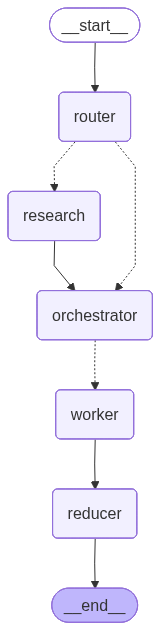

In [ ]:
# Main Graph.
graph = StateGraph(BlogState)

graph.add_node('router', router_node)
graph.add_node('research', research_node)
graph.add_node('orchestrator', orchestrator)
graph.add_node('worker', worker_node)
graph.add_node('reducer', reducer)

graph.add_edge(START, 'router')
graph.add_conditional_edges('router', next_router, {'research' : 'research', 'orchestrator' : 'orchestrator'})
graph.add_edge('research', 'orchestrator')

graph.add_conditional_edges('orchestrator', distribute_tasks, ['worker'])
graph.add_edge('worker', 'reducer')
graph.add_edge('reducer', END)

workflow = graph.compile()
workflow


# Running

In [ ]:
def run_statement(topic : str):
    output = workflow.invoke(
        {
        'topic' : topic,
        'require_research' : False,
        'research_method' : 'open_book',
        'queries' : [],
        'evidence' : [],
        'sections' : [],
        }
    )

    return output


In [42]:
run_statement('Write a blog on Claud Code.')

{'topic': 'Write a blog on Claud Code.',
 'research_method': 'close_book',
 'require_research': False,
 'queries': [],
 'evidence': [],
 'plan': Plan(blog_title='Unlocking the Power of Claud Code: A Comprehensive Guide', audience='software engineers interested in natural language processing', tone='professional but approachable', tasks=[Task(id=1, title='Why Claud Code Matters in NLP', description='This section covers the current state of NLP and the importance of Claud Code in this field.', goal='The reader will understand the significance of Claud Code in NLP and its potential applications.', target_words=450, bullets=['Claud Code is an open-source library for natural language processing tasks', 'It provides a unified interface for various NLP tasks, making it easier to integrate with other libraries', 'Claud Code has gained popularity in recent years due to its efficiency and flexibility', 'It supports a wide range of NLP tasks, including text classification, sentiment analysis, and